23102A0007 - Aarti Sakpal
# Social Network Analysis with R

## Aim

To implement Social Network Analysis using R by representing relationships between entities as nodes and edges, constructing and visualizing the network, calculating important network measures, identifying highly connected and influential nodes, and detecting communities.

## Introduction

Social Network Analysis (SNA) is a technique used to study relationships and interactions between entities.

In a social network:

- **Nodes (vertices)** represent entities such as people, organizations, or users.
- **Edges (links)** represent relationships or interactions between the entities.

Social Network Analysis helps identify highly connected individuals, influential nodes, clusters or communities, and the overall structure of a network.

In this experiment, R is used to construct, analyze, and visualize a social network. Network measures such as node degree are calculated, highly connected nodes are identified, and community detection is performed.

In [4]:
install.packages("igraph")
install.packages("ggplot2")
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [5]:
library(igraph)
library(ggplot2)
library(dplyr)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Attaching package: ‘dplyr’


The following objects are masked from ‘package:igraph’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [6]:
edges <- data.frame(
  from = c(
    "Alice", "Alice", "Alice",
    "Bob", "Bob",
    "Charlie", "Charlie",
    "David",
    "Eve", "Eve",
    "Frank",
    "Grace",
    "Henry"
  ),
  to = c(
    "Bob", "Charlie", "David",
    "Charlie", "Eve",
    "David", "Eve",
    "Eve",
    "Frank", "Grace",
    "Grace",
    "Henry",
    "Alice"
  )
)

edges

from,to
<chr>,<chr>
Alice,Bob
Alice,Charlie
Alice,David
Bob,Charlie
Bob,Eve
Charlie,David
Charlie,Eve
David,Eve
Eve,Frank


In [7]:
network <- graph_from_data_frame(
  edges,
  directed = FALSE
)

network

IGRAPH 6b303b4 UN-- 8 13 -- 
+ attr: name (v/c)
+ edges from 6b303b4 (vertex names):
 [1] Alice  --Bob     Alice  --Charlie Alice  --David   Bob    --Charlie
 [5] Bob    --Eve     Charlie--David   Charlie--Eve     David  --Eve    
 [9] Eve    --Frank   Eve    --Grace   Frank  --Grace   Grace  --Henry  
[13] Alice  --Henry  

In [8]:
cat("Number of Nodes:", vcount(network), "\n")
cat("Number of Edges:", ecount(network), "\n")

Number of Nodes: 8 
Number of Edges: 13 


In [9]:
V(network)$name

[1] "Alice"   "Bob"     "Charlie" "David"   "Eve"     "Frank"   "Grace"  
[8] "Henry"

In [10]:
degree_values <- degree(network)

degree_values

Alice     Bob Charlie   David     Eve   Frank   Grace   Henry 
      4       3       4       3       5       2       3       2

In [11]:
degree_table <- data.frame(
  Node = names(degree_values),
  Degree = as.numeric(degree_values)
)

degree_table

Node,Degree
<chr>,<dbl>
Alice,4
Bob,3
Charlie,4
David,3
Eve,5
Frank,2
Grace,3
Henry,2


In [12]:
degree_table <- degree_table %>%
  arrange(desc(Degree))

degree_table

Node,Degree
<chr>,<dbl>
Eve,5
Alice,4
Charlie,4
Bob,3
David,3
Grace,3
Frank,2
Henry,2


In [13]:
most_connected <- degree_table[1, ]

most_connected

,Node,Degree
,<chr>,<dbl>
1,Eve,5


In [14]:
cat(
  "Most connected node:",
  most_connected$Node,
  "\nDegree:",
  most_connected$Degree
)

Most connected node: Eve 
Degree: 5

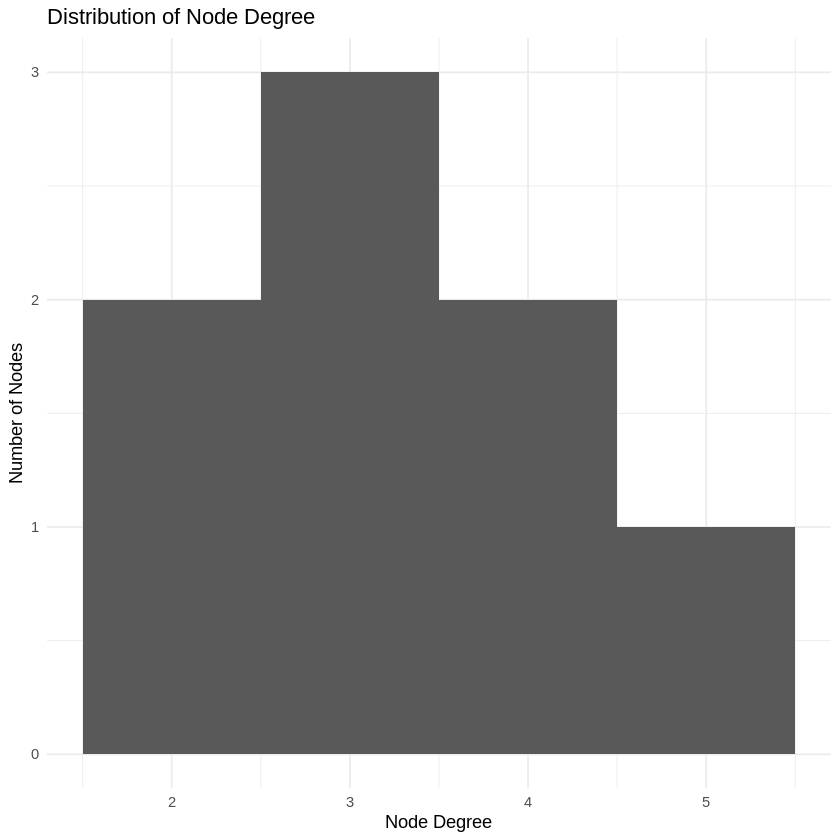

In [15]:
degree_df <- data.frame(
  Node = names(degree_values),
  Degree = as.numeric(degree_values)
)

ggplot(degree_df, aes(x = Degree)) +
  geom_histogram(
    binwidth = 1,
    boundary = 0.5
  ) +
  labs(
    title = "Distribution of Node Degree",
    x = "Node Degree",
    y = "Number of Nodes"
  ) +
  theme_minimal()

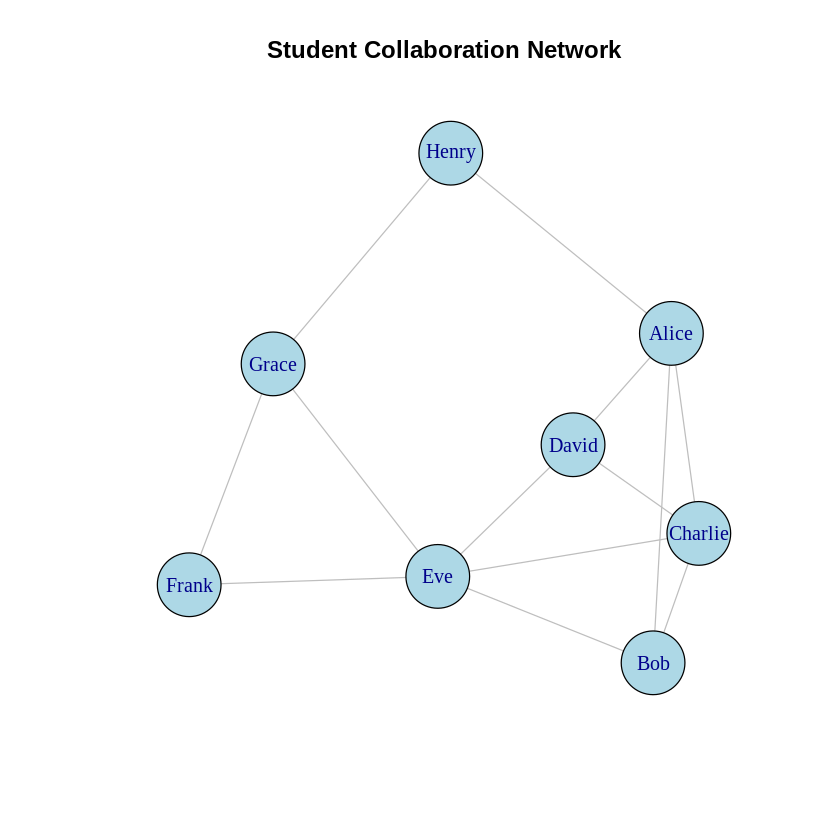

In [16]:
set.seed(123)

plot(
  network,
  vertex.label = V(network)$name,
  vertex.size = 25,
  vertex.color = "lightblue",
  vertex.frame.color = "black",
  edge.color = "gray",
  main = "Student Collaboration Network"
)

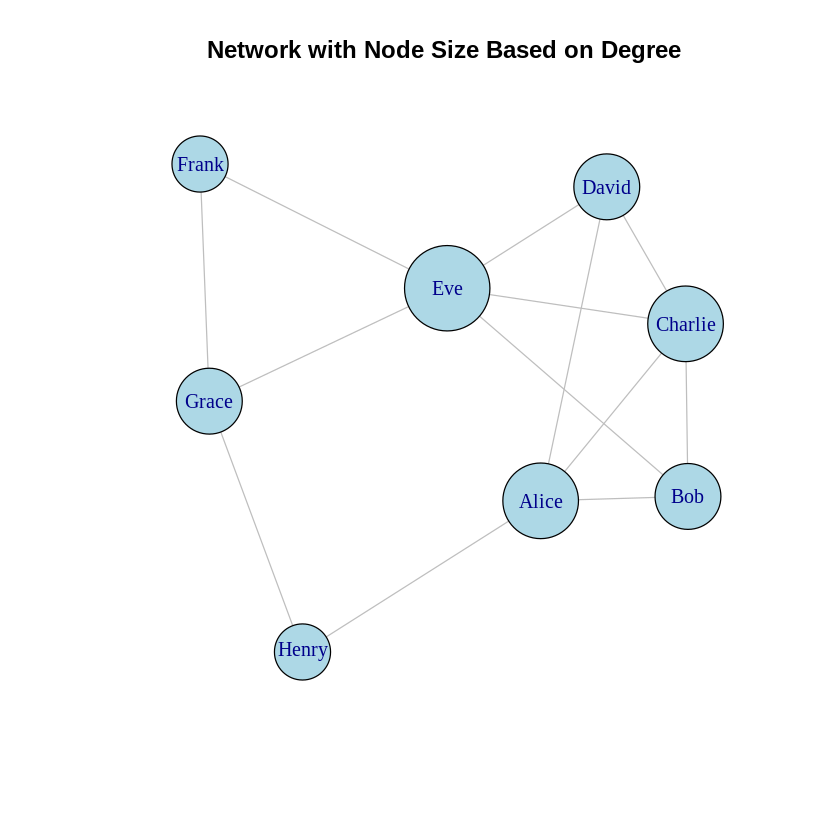

In [17]:
node_degree <- degree(network)

plot(
  network,
  vertex.label = V(network)$name,
  vertex.size = 15 + node_degree * 4,
  vertex.color = "lightblue",
  vertex.frame.color = "black",
  edge.color = "gray",
  main = "Network with Node Size Based on Degree"
)

In [18]:
mean(degree(network))

[1] 3.25

In [19]:
edge_density(network)

[1] 0.4642857

In [20]:
components(network)$no

[1] 1

In [21]:
diameter(network)

[1] 3

In [22]:
mean_distance(network)

[1] 1.571429

In [23]:
cat("Number of Nodes:", vcount(network), "\n")
cat("Number of Edges:", ecount(network), "\n")
cat("Average Degree:", round(mean(degree(network)), 2), "\n")
cat("Network Density:", round(edge_density(network), 3), "\n")
cat("Number of Components:", components(network)$no, "\n")
cat("Network Diameter:", diameter(network), "\n")
cat("Average Path Length:", round(mean_distance(network), 2), "\n")

Number of Nodes: 8 
Number of Edges: 13 
Average Degree: 3.25 
Network Density: 0.464 
Number of Components: 1 
Network Diameter: 3 
Average Path Length: 1.57 


In [24]:
degree_centrality <- degree(network)

betweenness_centrality <- betweenness(
  network,
  normalized = TRUE
)

centrality_table <- data.frame(
  Node = V(network)$name,
  Degree = degree_centrality,
  Betweenness = round(betweenness_centrality, 3)
)

centrality_table

,Node,Degree,Betweenness
,<chr>,<dbl>,<dbl>
Alice,Alice,4,0.159
Bob,Bob,3,0.028
Charlie,Charlie,4,0.044
David,David,3,0.028
Eve,Eve,5,0.337
Frank,Frank,2,0.000
Grace,Grace,3,0.107
Henry,Henry,2,0.060


In [25]:
centrality_table %>%
  arrange(desc(Degree))

,Node,Degree,Betweenness
,<chr>,<dbl>,<dbl>
Eve,Eve,5,0.337
Alice,Alice,4,0.159
Charlie,Charlie,4,0.044
Bob,Bob,3,0.028
David,David,3,0.028
Grace,Grace,3,0.107
Frank,Frank,2,0.000
Henry,Henry,2,0.060


In [26]:
hits_result <- authority_score(network)

authority_table <- data.frame(
  Node = V(network)$name,
  Authority = round(hits_result$vector, 3)
)

authority_table %>%
  arrange(desc(Authority))

Warning message:
“`authority_score()` was deprecated in igraph 2.1.0.
ℹ Please use `hits_scores()` instead.”


,Node,Authority
,<chr>,<dbl>
Eve,Eve,1.000
Charlie,Charlie,0.977
Alice,Alice,0.841
Bob,Bob,0.800
David,David,0.800
Grace,Grace,0.515
Frank,Frank,0.430
Henry,Henry,0.385


In [27]:
hub_result <- hub_score(network)

hub_table <- data.frame(
  Node = V(network)$name,
  Hub = round(hub_result$vector, 3)
)

hub_table %>%
  arrange(desc(Hub))

Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”


,Node,Hub
,<chr>,<dbl>
Eve,Eve,1.000
Charlie,Charlie,0.977
Alice,Alice,0.841
Bob,Bob,0.800
David,David,0.800
Grace,Grace,0.515
Frank,Frank,0.430
Henry,Henry,0.385


In [28]:
communities <- cluster_louvain(network)

communities

IGRAPH clustering multi level, groups: 2, mod: 0.19
+ groups:
  $`1`
  [1] "Alice"   "Bob"     "Charlie" "David"  
  
  $`2`
  [1] "Eve"   "Frank" "Grace" "Henry"
  

In [29]:
community_table <- data.frame(
  Node = V(network)$name,
  Community = membership(communities)
)

community_table

,Node,Community
,<chr>,<membrshp>
Alice,Alice,1
Bob,Bob,1
Charlie,Charlie,1
David,David,1
Eve,Eve,2
Frank,Frank,2
Grace,Grace,2
Henry,Henry,2


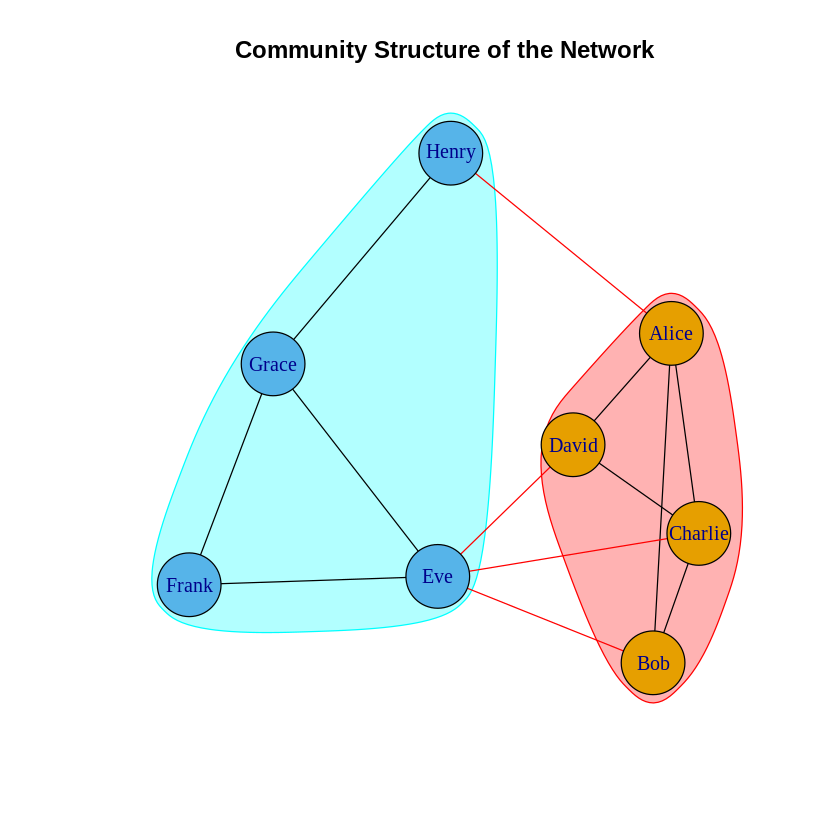

In [30]:
set.seed(123)

plot(
  communities,
  network,
  vertex.label = V(network)$name,
  vertex.size = 25,
  main = "Community Structure of the Network"
)

In [31]:
sizes(communities)

Community sizes
1 2 
4 4 

In [32]:
cat(
  "Number of detected communities:",
  length(sizes(communities)),
  "\n"
)

sizes(communities)

Number of detected communities: 2 


Community sizes
1 2 
4 4 

## Important Results

The Social Network Analysis produced the following results:

- The network contains **8 nodes** representing individuals.
- The network contains **13 edges** representing relationships between individuals.
- The average degree of the network is **3.25**, indicating that an individual has approximately 3.25 direct connections on average.
- The network density is **0.464**, indicating that approximately 46.4% of the possible connections are present in the network.
- The network contains **1 connected component**, which means all individuals are connected directly or indirectly.
- The network diameter is **3**, meaning the greatest shortest-path distance between any two nodes is 3.
- The average path length is **1.57**, indicating that nodes are generally separated by a small number of connections.
- **Eve** has the highest degree with **5 connections** and is the most highly connected node.
- Eve also has the highest betweenness centrality with a value of **0.337**, indicating an important bridging position in the network.
- Community detection identified **2 communities**, each containing **4 nodes**.

## Interpretation of Results

The analysis shows that the social network is a connected network containing 8 individuals and 13 relationships. Since the number of connected components is 1, every individual can reach every other individual through one or more relationships.

The average degree of 3.25 indicates that each individual has approximately three direct connections on average. The network density of 0.464 shows a moderate level of connectivity, meaning that a substantial portion of the possible relationships exists within the network.

Eve is the most highly connected individual, with a degree of 5. Therefore, Eve can be considered the most connected node in the network. Eve also has the highest betweenness centrality value of 0.337, suggesting that Eve plays an important role in connecting different parts of the network.

Alice and Charlie have the next highest degree values, with 4 connections each. Alice has a betweenness centrality of 0.159, which also indicates a relatively important position in the network.

The HITS analysis provides hub and authority scores for the nodes. Eve has the highest score, followed by Charlie and Alice, indicating that these nodes occupy important positions according to the HITS analysis.

The Louvain community detection algorithm identified two communities, each containing four individuals. The first community contains Alice, Bob, Charlie, and David, while the second contains Eve, Frank, Grace, and Henry. This indicates the presence of two distinct groups within the network.

Overall, the network measures demonstrate that Eve is the most prominent node based on both connectivity and betweenness, while the community analysis reveals two major groups within the social network.

## Community Detection Results

The Louvain community detection algorithm identified **two communities** in the social network.

### Community 1
- Alice
- Bob
- Charlie
- David

### Community 2
- Eve
- Frank
- Grace
- Henry

Each community contains four nodes. The result indicates that the network can be divided into two groups based on the connectivity patterns between the nodes.

## Conclusion

Social Network Analysis was successfully implemented using R and the `igraph` package.

The experiment demonstrated how individuals can be represented as nodes and their relationships as edges. The constructed network was analyzed using degree, betweenness centrality, network density, diameter, average path length, HITS scores, and community detection.

The analysis identified Eve as the most highly connected and influential node based on her degree and betweenness centrality. The network was found to be fully connected through a single component, with a moderate density of 0.464.

Community detection identified two groups of four individuals each, demonstrating how network analysis can reveal underlying groups and structural patterns.

Therefore, the experiment demonstrates the usefulness of R for representing, analyzing, visualizing, and interpreting relationship-based data using Social Network Analysis techniques.